In [1]:
## Create a vector of the required packages for this analysis
req_packages <- c("ComplexHeatmap", "cowplot", "edgeR", "ggplot2", "ggpubr", "ggrepel", "gridExtra", 
                  "janitor", "multcompView","patchwork", "RColorBrewer", "RUVSeq", "splines", 
                  "stringr", "tidyverse", "vegan", "viridis")

## load the packages, quietly
invisible(suppressWarnings(suppressMessages(
    lapply(req_packages, require, character.only = TRUE)
)))

## Characterize genetic variation

### Load in data

In [2]:
# ## load in filtered snpeff results
# snpeff_raw <- read_tsv("input/vg_annotated.snpsift_high.vcf", skip = 519) %>%
#     janitor::clean_names()

# ## separate the results information wider
# snpeff_high <- snpeff_raw %>%
#     # filter(!grepl("intergenic_region", info)) %>%
#     pivot_longer(10:ncol(snpeff_raw), names_to = "strain", values_to = "presence") %>%
#     # separate_wider_delim(info, delim = ";", names = c("depth", "read_transversal", "info")) %>%
#     separate_wider_delim(info, delim = "|", too_many = "merge",
#                          names = c("annotation", "annotation_impact", "gene_name", "gene_id", "feature_type", 
#                                    "feature_id", "transcript_biotype", "rank", "HGVS.c", "HGVS.p", 
#                                    "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
#                                    "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
#     separate_wider_delim(presence, delim = ":", too_many = "merge", 
#                          names = c("genotype", "read_depth", "ref.depth_alt.depth", "genotype_likelihood", 
#                                    "phred", "genotype_probability", "expected_depth", 
#                                    "minimum_site_allele_depth")) %>%
#     separate_longer_delim(annotation_impact, delim = "&")

# write_tsv(snpeff_high, "intermediate/snpeff_high.tsv")

In [3]:
## load in high effect SNP information
snpeff_high <- read_tsv("intermediate/snpeff_high.tsv")

Rows: 5981004 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): number_chrom, id, ref, alt, filter, annotation, annotation_impact,...
dbl  (3): pos, qual, ERRORS_WARNINGS_INFO

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
## load in chromosome bp
chromosome_size <- read_tsv("input/dame_g96.chrom.sizes", col_names = FALSE)
colnames(chromosome_size) <- c("number_chrom", "size_bp")
chromosome_size <- chromosome_size %>%
    filter(grepl("Chr", number_chrom))

## load in high effect SNP information
snpeff_high <- read_tsv("intermediate/snpeff_high.tsv")

## load in metadata
metadata <- read_csv("input/YABLab_Drosophila_stocks.csv") %>%
    janitor::clean_names() %>%
    filter(!is.na(latitude)) %>%
    mutate(strain_id = tolower(strain_id),
           strain_id = str_replace_all(strain_id, "\\.", "_")) %>%
    separate_wider_delim(strain_id, delim = "_", names = c("location", "female", "number"), too_few = "align_start", too_many = "drop")

## load in the strain list
strain_list <- read_tsv("input/pops_origin.tsv", col_names = FALSE) %>%
    mutate_all(., tolower)
colnames(strain_list) <- c("strain", "location")

head(strain_list)
head(snpeff_high)
head(metadata)

Rows: 6 Columns: 2


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 5981004 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): number_chrom, id, ref, alt, filter, annotation, annotation_impact,...
dbl  (3): pos, qual, ERRORS_WARNINGS_INFO

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 294 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): species_group, Species, strain_ID, strain_type, Genotype, label, s...
dbl  (5): year, latitude, longitude, water_distance_mi, riparian_year

ℹ Use `spec()` to retrieve the full column specificatio

strain,location
<chr>,<chr>
aa_99_06,aa
aa_99_06,aa
bb_05_10,bb
bb_05_10,bb
bb_05_18,bb
bb_05_18,bb


number_chrom,pos,id,ref,alt,qual,filter,annotation,annotation_impact,gene_name,⋯,format,strain,genotype,read_depth,ref.depth_alt.depth,genotype_likelihood,phred,genotype_probability,expected_depth,minimum_site_allele_depth
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,aa_99_06,0/0,5,"5,0","-1.6658,-2.41599,-12.4051",7,-1.26222,3.39241,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_10,0/0,3,"3,0","-1.15467,-1.58018,-7.57366",4,-1.41736,3.56962,3
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_18,0/0,5,"5,0","-1.35211,-2.27185,-12.261",9,-1.21221,5.01266,5
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_36,0/0,11,"11,0","-3.88771,-6.0703,-28.0464",21,-1.10516,3.97468,11
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_44,0/0,15,"15,0","-2.1338,-5.78636,-35.7538",36,-1.09883,11.2278,15
Chr_2,782762,>48617>48619,GGA,G,1328.29,lowdepth;lowad,"DP=1466;AT=>48617>48618>48619,>48617>48619;AF=0.291667;ANN=G",frameshift_variant,HIGH,⋯,GT:DP:AD:GL:GQ:GP:XD:MAD,bb_05_46,1/0,7,"3,4","-9.19754,-1.71297,-6.9283",52,-1.09862,4.3038,3


species_group,species,location,female,number,strain_type,genotype,label,year,slot,⋯,state,country,latitude,longitude,sequencing,wetland,water_distance_mi,water_source,riparian,riparian_year
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
virilis,D. americana,aa,99,06,wild-type,wt,NA,1999,A5-5,⋯,AR,USA,35.28654,-91.38307,nextera_2020,No,0.08,Riverine,NA,1980
virilis,D. americana,bb,05,10,wild-type,wt,NA,2005,A6-1,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,18,wild-type,wt,NA,2005,A6-2,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,36,wild-type,wt,NA,2005,A6-3,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,red,mutant,red,NA,2005,A6-4,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980
virilis,D. americana,bb,05,44,wild-type,wt,NA,2005,A6-5,⋯,TN,USA,36.46119,-89.31181,NA,Freshwater Forested/Shrub Wetland,0.04,Riverine,NA,1980


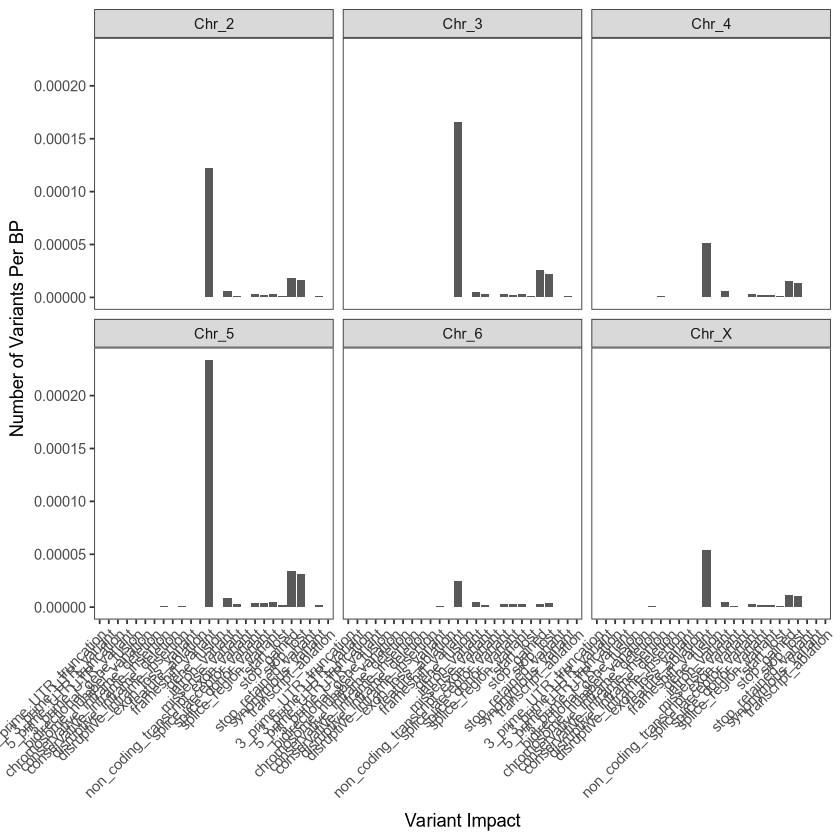

In [5]:
## plot the number of variants with each impact, per chromosome
impact_chromosome <- snpeff_high %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, annotation_impact) %>%
    unique() %>%
    group_by(number_chrom, annotation_impact) %>%
    count() %>%
    left_join(chromosome_size, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(normal = n/size_bp) %>%
    ggplot(aes(x = annotation_impact, y = normal)) +
        geom_bar(stat = "identity") +
        labs(x = "Variant Impact", y = "Number of Variants Per BP") +
        theme_bw() +
        theme(panel.grid = element_blank(),
              axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
        facet_wrap(~ number_chrom)
impact_chromosome

In [6]:
ggsave("figures/highimpact_variant_chromosome_bp.png", impact_chromosome, height = 10, width = 15)

### Calculate heterozygosity for high impact alleles

`mutate_all()` ignored the following grouping variables:
• Columns `number_chrom`, `pos`, `alt`, `location`, `genotype`
ℹ Use `mutate_at(df, vars(-group_cols()), myoperation)` to silence the message.
Warning message in left_join(., het_pop, by = "location"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


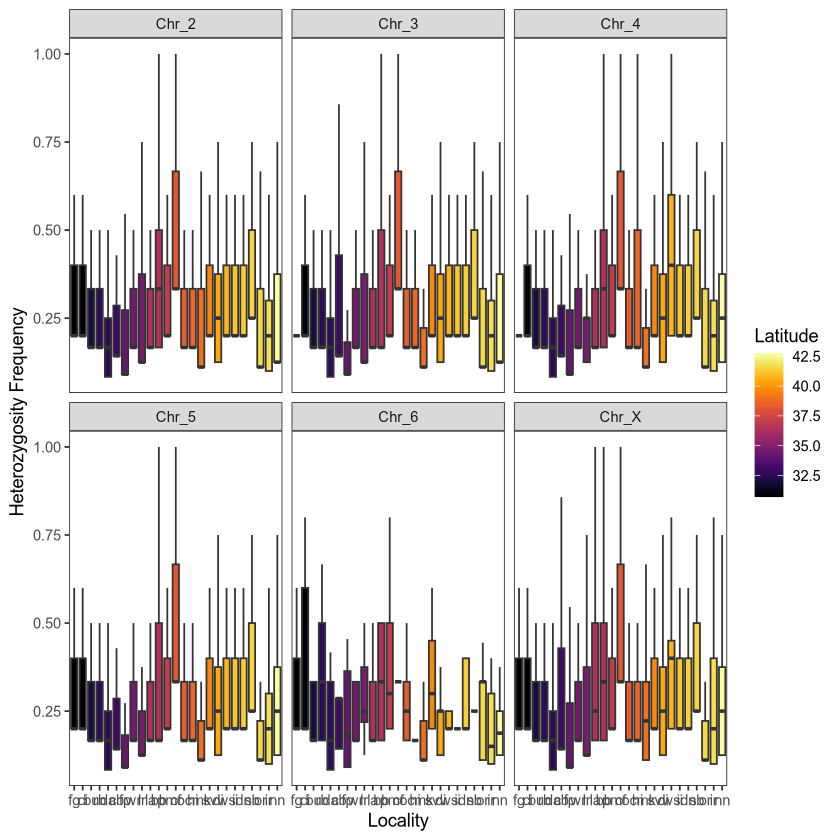

In [7]:
## count the total number of strains per population 
strain_pop <- snpeff_high %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location) %>%
    count() %>%
    rename(total = n)

## count the number of heterozygotes
het_pop <- snpeff_high %>%
    filter(grepl("Chr", number_chrom) & (genotype == "1/0" | genotype == "0/1")) %>%
    # filter(grepl("stop", annotation_impact)) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, location, genotype) %>%
    count() %>%
    mutate_all(~replace_na(., 0)) %>%
    left_join(strain_pop, by = c("number_chrom", "pos", "alt", "location")) %>%
    mutate(het_freq = n/total)

## plot heterozygosity
het_graph <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location") %>%
    filter(total > 2) %>%
    na.omit() %>%
    ggplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude)) +
    geom_boxplot(outlier.shape = NA) +
    labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
    scale_fill_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank(),
          legend.positino = "bottom") +
    facet_wrap(~number_chrom)

het_graph

In [8]:
ggsave("figures/heterozygosity_pop.png", het_graph, height = 12, width = 25)

Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


Warning message in plot_theme(plot):
“The `legend.positino` theme element is not defined in the element hierarchy.”


In [9]:
## create empty data frame to populate
number_chrom <- unique(het_pop$number_chrom)

het_pop_ttest <- matrix(data = NA, nrow = 1, ncol = 3,
                        dimnames = list(c("remove"),
                                        c("number_chrom", "location", "p_value"))) %>%
                as.data.frame()

## calculate how much the heterozygosity frequency deviates from expected for each location per chromosome
for (i in number_chrom) {
    
    ## pull the list of heterozygosity frequencies for the entire chromosome, across populations
    y <-  het_pop %>%
        filter(number_chrom == i) %>%
        pull("het_freq")

    for (j in unique(het_pop$location)) {    
        
        ## pull the heterozygosity frequencies for the location on chromosome
        x <- het_pop %>%
            filter(number_chrom == i & location == j) %>%
            pull("het_freq")
            
        if (length(x) > 2) {        
            ## run the t-test
            test <- t.test(x = x, y = y, alternative = "greater")

            ## populate the data frame
            het_pop_ttest <- het_pop_ttest %>%
                add_row(number_chrom = i, location = j, p_value = test$p.value)

        }
    }
}

## filter out the removed row
het_pop_ttest <- het_pop_ttest %>%
    na.omit()
head(het_pop_ttest)

,number_chrom,location,p_value
,<chr>,<chr>,<dbl>
...2,Chr_2,bb,0.9999924
...3,Chr_2,bu,1.0000000
...4,Chr_2,cb,1.0000000
...5,Chr_2,da,1.0000000
...6,Chr_2,di,1.0000000
...7,Chr_2,fp,1.0000000


Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


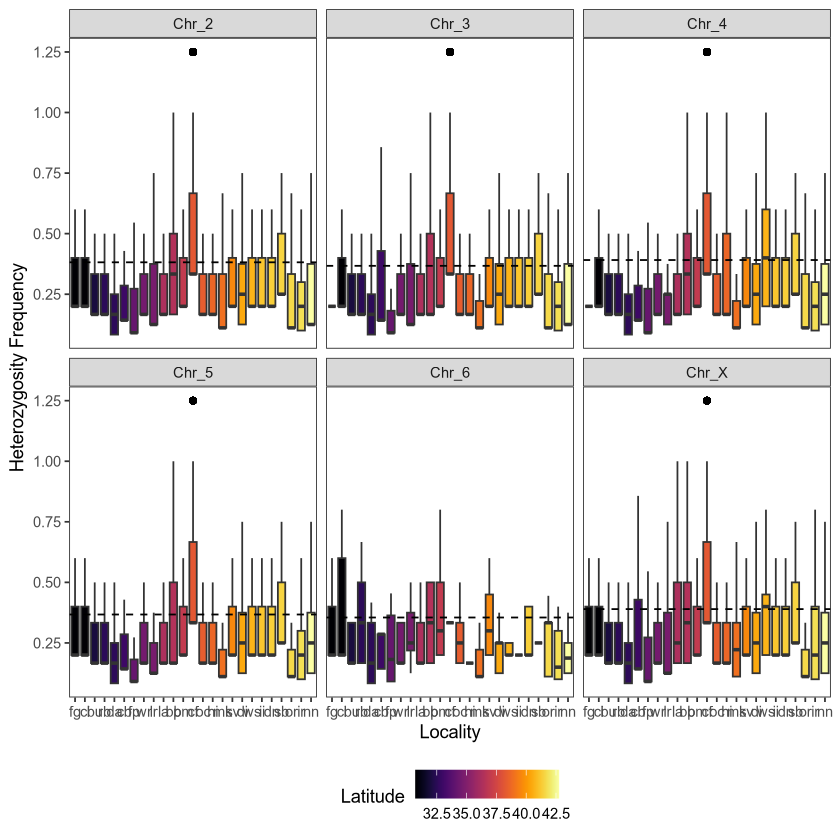

In [10]:
## calculate the average heterozygosity per chromosome
chrom_het_avg <- het_pop %>%
    group_by(number_chrom) %>%
    summarize(probability = mean(het_freq))

## plot the number of populations that deviate from the chromosomal mean
het_graph_deviate <- metadata %>%
    select(location, latitude) %>%
    left_join(het_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 2) %>%
    na.omit() %>%
    left_join(het_pop_ttest, by = c("number_chrom", "location"), relationship = "many-to-many") %>%
    left_join(chrom_het_avg, by = "number_chrom", relationship = "many-to-many") %>%
    mutate(deviate = case_when(p_value < 0.05 ~ 1.25,
                               TRUE ~ NA)) %>%
    ggplot() +
        geom_boxplot(aes(x = fct_reorder(location, latitude), y = het_freq, fill = latitude), outlier.shape = NA) +
        geom_hline(aes(yintercept = probability), linetype = "dashed") +
        geom_point(aes(x = fct_reorder(location, latitude), y = deviate)) +
        labs(x = "Locality", y = "Heterozygosity Frequency", fill = "Latitude") +
        scale_fill_viridis(option = "B") +
        theme_bw() +
        theme(panel.grid = element_blank(),
            legend.position = "bottom") +
        facet_wrap(~number_chrom)
het_graph_deviate

In [11]:
ggsave("figures/heterozygosity_pop_deviate.png", het_graph_deviate, height = 6, width = 12)

Warning message:
“Removed 311801 rows containing missing values or values outside the scale range
(`geom_point()`).”


### Calculate frequency of high impact alleles per population

In [12]:
## calculate the number of alleles per population
strain_number <- strain_list %>%
    group_by(location) %>%
    count() %>%
    rename(total = n) %>%
    mutate(total = total*2)

## calculate the frequency of each allele in each population
snpeff_pop <- snpeff_high %>%
    filter(grepl("Chr", number_chrom)) %>%
    select(number_chrom, pos, alt, genotype, strain) %>%
    unique() %>%
    separate_wider_delim(strain, delim = "_", names = c("location", "female", "number"), too_few = "align_start") %>%
    group_by(number_chrom, pos, alt, genotype, location) %>%
    count() %>%
    rename(presence = n) %>%
    mutate(presence = case_when(genotype == "1/1" ~ presence*2,
                               genotype == "0/1" ~ presence,
                               TRUE ~ 0)) %>%
    group_by(number_chrom, pos, alt, location) %>%
    reframe(presence_total = sum(presence)) %>%
    right_join(strain_number, by = "location") %>%
    mutate(total = case_when(presence_total > total ~ presence_total,
                             TRUE ~ total),
           ratio = presence_total/total)

head(snpeff_pop)

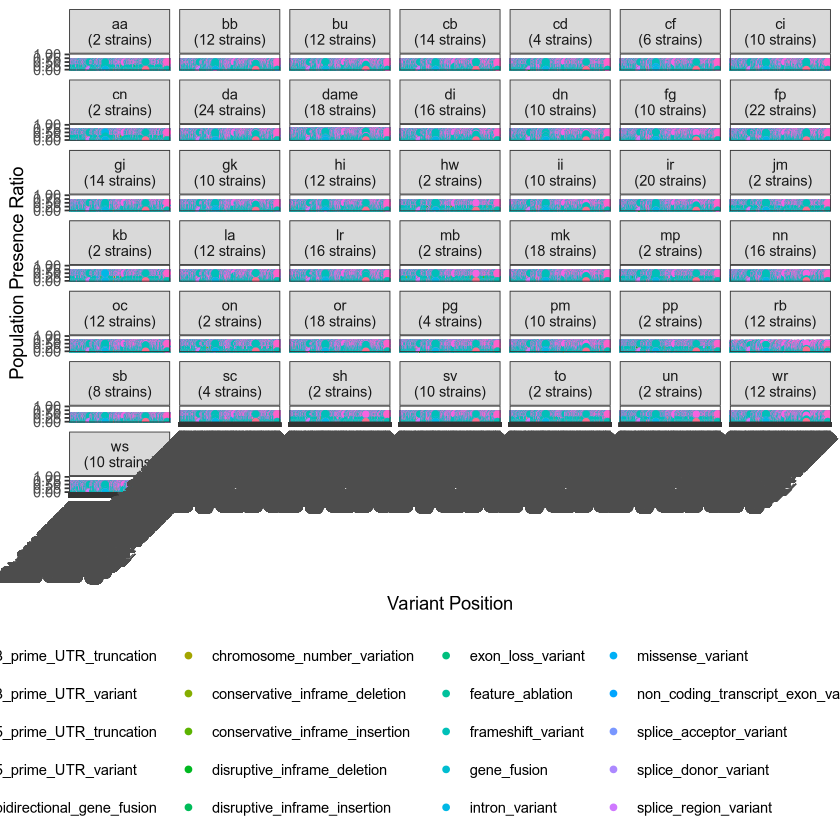

In [ ]:
## add annotation information to population frequency
impact_pop <- snpeff_high %>%
    select(number_chrom, pos, annotation_impact) %>%
    unique() %>%
    right_join(snpeff_pop, by = c("number_chrom", "pos"), relationship = "many-to-many")

## plot the frequency of each allele per population
pop_graph <- impact_pop %>%
    mutate(position = paste(number_chrom, pos),
           name = paste0(location, "\n(", total/2, " strains)")) %>%
    filter(annotation_impact != "synonymous_variant") %>%
    ggplot(aes(x = position, y = ratio, color = annotation_impact), alpha = 0.5) +
        geom_point() +
        ylim(0, 1) +
        labs(x = "Variant Position", y = "Population Presence Ratio",
             color = "Variant Impact") +
        theme_bw() +
        theme(panel.grid = element_blank(),
              axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              legend.position = "bottom") +
        facet_wrap(~name)
pop_graph

In [ ]:
ggsave("figures/highimpact_freq_pop.png", pop_graph, height = 12, width = 25)

In [ ]:
## determine if there is a difference in number of high impact mutation per chromosome
impact_lat_pop <- metadata %>%
    select(location, latitude) %>%
    unique() %>%
    left_join(impact_pop, by = "location", relationship = "many-to-many") %>%
    filter(total > 5)

chrom_anova <- aov(ratio ~ number_chrom + annotation_impact, data = impact_lat_pop)
summary(chrom_anova)

In [ ]:
## perform post hoc test
chrom_tukey <- TukeyHSD(chrom_anova)

## group the chromosomes based on Tukey test
chrom_groups <- multcompLetters4(chrom_anova, chrom_tukey)
impact_lat_pop_groups <- as.data.frame.list(chrom_groups$number_chrom) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("number_chrom") %>%
    full_join(impact_lat_pop, by = "number_chrom", relationship = "many-to-many")

## add groups to plot
impact_lat_pop_box <- impact_lat_pop_groups %>%
    ggplot(aes(x = number_chrom, y = ratio)) +
    # geom_jitter(aes(color = latitude), alpha = 0.1) +
    geom_boxplot(fill = NA, linewidth = 1.5) +
    geom_text(aes(label = group, y = 1.1)) +
    labs(x = "Chromosome", y = "Variant Frequency per Population",
         color = "Population Latitude") +
    scale_color_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank())
impact_lat_pop_box

In [ ]:
ggsave("figures/highimpact_freq_chrom.png", impact_lat_pop_box, height = 12, width = 25)

In [ ]:
## determine correlation between latitude and theta
ratio_lat <- impact_lat_pop %>%
    ungroup() %>%
    select(latitude, ratio) %>%
    unique()

cor.test(ratio_lat$latitude, ratio_lat$ratio, method = "pearson")

In [ ]:
## calculate correlation of theta and latitude for each chromosome
number_chrom <- unique(impact_lat_pop$number_chrom)
ratio_lat_mx <- matrix(data = NA, nrow = length(number_chrom), ncol = 2, 
       dimnames = list(c(number_chrom),
                       c("correlation", "pvalue")))

for (i in number_chrom) {

    ratio_lat_chr <- impact_lat_pop %>%
        ungroup() %>%
        filter(number_chrom == i) %>%
        select(latitude, ratio) %>%
        unique
    correlation <- cor.test(ratio_lat_chr$latitude, ratio_lat_chr$ratio, method = "pearson")
    ratio_lat_mx[[i, "correlation"]] <- correlation$estimate
    ratio_lat_mx[[i, "pvalue"]] <- correlation$p.value
}

ratio_lat_mx

In [ ]:
## calculate the variance of allele frequency between populations, by chromosome
impact_lat_var <- impact_lat_pop %>%
    group_by(number_chrom, location, latitude) %>%
    summarize(frequency_variance = var(ratio))

chrom_var_anova <- aov(frequency_variance ~ number_chrom, data = impact_lat_var)
summary(chrom_var_anova)

In [ ]:
## perform post hoc test
chrom_var_tukey <- TukeyHSD(chrom_var_anova)

## group the chromosomes based on Tukey test
chrom_var_groups <- multcompLetters4(chrom_var_anova, chrom_var_tukey)
impact_lat_var_groups <- as.data.frame.list(chrom_var_groups$number_chrom) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("number_chrom") %>%
    full_join(impact_lat_var, by = "number_chrom", relationship = "many-to-many")

## add groups to plot
impact_lat_var_box <- impact_lat_var_groups %>%
    ggplot(aes(x = number_chrom, y = frequency_variance)) +
    geom_jitter(aes(color = latitude)) +
    geom_boxplot(fill = NA, outlier.shape = NA) +
    geom_text(aes(label = group, y = 0.06)) +
    labs(x = "Chromosome", y = "Variant Frequency Variance per Population",
         color = "Population Latitude") +
    scale_color_viridis(option = "B") +
    theme_bw() +
    theme(panel.grid = element_blank())
impact_lat_var_box

In [ ]:
ggsave("figures/highimpact_freq_var_chrom.png", impact_lat_var_box, height = 6, width = 12)

In [ ]:
cor.test(impact_lat_var$frequency_variance, impact_lat_var$latitude, method = "pearson")

## Characterize gene expression variation

#### Characterize multigenome alignment

In [ ]:
## load in alignment summary file
alignment_raw <- read_tsv("../workflow/rna/multigenome/results/multigenome_alignment.tsv")

## separate out file name into strain and genome name
alignment <- alignment_raw %>%
    separate_wider_delim(sample, delim = "_", names = c("hisat2", "locality", "female", "number", "replicate", "genome"), too_few = "align_start", cols_remove = FALSE) %>% 
    select(-hisat2) %>%
    mutate(genome = case_when(is.na(genome) ~ replicate,
                              TRUE ~ genome),
           replicate = case_when(replicate == genome ~ number,
                                 TRUE ~ replicate),
           number = case_when(number == replicate ~ "0",
                              TRUE ~ number),
           strain = paste(locality, female, number, sep = "_")) %>%
    relocate(strain, 1)
head(alignment)

In [ ]:
## determine if there is overall a better mapping to a single genome
align_anova <- aov(percent_aligned ~ genome + locality, data = alignment)
summary(align_anova)

In [ ]:
## determine which genome comparison is driving this difference
align_tukey <- TukeyHSD(align_anova)

## group the chromosomes based on Tukey test
align_groups <- multcompLetters4(align_anova, align_tukey)
alignment_groups <- as.data.frame.list(align_groups$genome) %>%
    mutate(group = Letters) %>%
    select(group) %>%
    rownames_to_column("genome") %>%
    full_join(alignment, by = "genome")

align_tukey$genome

In [ ]:
## plot alignment for each strain
alignment_box <- alignment_groups %>%
    ggplot(aes(x = genome, y = percent_aligned)) +
        geom_boxplot(outlier.shape = NA) +
        geom_text(aes(label = group, y = 100), size = 8) +
        labs(x = "Genome", y = "Percent of Reads Aligned") +
        ylim(75, 100) +
        theme_bw()
alignment_box

In [ ]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_boxplot.png", alignment_box)

In [ ]:
## get latitude for each population
local_lat <- metadata %>%
    select(strain_id, latitude) %>%
    separate_wider_delim(strain_id, delim = ".", names = c("locality", "female", "number"), too_few = "align_start", too_many = "drop") %>%
    filter(locality %in% alignment$locality) %>%
    select(locality, latitude) %>%
    na.omit() %>%
    unique()

## combine files
lat_alignment <- alignment %>%
    left_join(local_lat, by = "locality")

lat_plot <- lat_alignment %>%
    na.omit() %>%
    ggplot(aes(x = percent_aligned, y = latitude, color = genome)) +
        geom_point() +
        xlim(75, 100) +
        labs(x = "Percent of Reads Aligned", y = "Latitude", color = "Genome Aligned") +
        theme_minimal()
lat_plot

In [ ]:
## save figure
ggsave("figures/sb_alignment/multigenome_alignment_latitude.png", lat_plot)

In [ ]:
## determine if there is a significant correlation between latitude and genome
df_g96 <- lat_alignment %>%
    filter(genome == "G96")
cor.test(df_g96$latitude, df_g96$percent_aligned)

df_sb <- lat_alignment %>%
    filter(genome == "SB.02.06")
cor.test(df_sb$latitude, df_sb$percent_aligned)

df_ml <- lat_alignment %>%
    filter(genome == "ML.97.05")
cor.test(df_ml$latitude, df_ml$percent_aligned)

In [ ]:
## find the genome with the highest alignment for each sample
max_align <- alignment %>%
    select(strain, replicate, genome, percent_aligned) %>%
    mutate(sample = paste(strain, replicate, sep = "_")) %>%
    group_by(sample) %>%
    summarize(genome = genome[which.max(percent_aligned)])

In [ ]:
unique(max_align$genome)

### Load in data

In [ ]:
## load in gene expression data frames
counts_sb <- read_tsv("../workflow/rna/multigenome/results/abundances/SB.02.06/stringtie_gene_matrix.txt")
names_sb <- colnames(counts_sb) %>%
    as.data.frame()
colnames(names_sb) <- "name"

samples_sb <- names_sb %>%
    mutate(name = str_remove_all(name, "/home/clavery/projects/dagrp/dagrp_zwa/workflow/rna_alt/results/HISAT-2/SB.02.06/"),
           name = str_remove_all(name, ".csorted.hisat2.bam")) %>%
    filter(grepl("SB", name)) %>%
    mutate(name = str_remove_all(name, "_SB.02.06")) %>%
    pull("name")
colnames_sb <- c("gene", samples_sb)
colnames(counts_sb) <- colnames_sb

raw_counts <- counts_sb %>%
    column_to_rownames("gene")

In [ ]:
## load in GTF
gtf_raw <- read_tsv("/home/yahmed-labshare/data/genomes/virilis_group/americana/SB.02.06/Muller/Polished/gffcompare/sb.02.06.combined.gtf", col_names = FALSE)

## clean up GTF for downstream use
colnames(gtf_raw) <- c("chromosome", "source", "feature", "start", "end", "score", "strand", "frame", "attribute")
gtf <- gtf_raw %>%
    filter(feature == "transcript") %>%
    mutate(attribute = str_remove_all(attribute, "\""),
           attribute = str_remove_all(attribute, " "),
           chromosome = str_remove_all(chromosome, "_RagTag")) %>%
    separate_wider_delim(attribute, delim = ";", names = c("transcript", "gene_id", "gene", "extra"), too_many = "drop") %>%
    mutate(transcript = str_remove_all(transcript, "transcript_id"),
           gene_id = str_remove_all(gene_id, "gene_id"),
           gene = str_remove_all(gene, "oId"),
           gene = str_remove_all(gene, "gene_name"),
           extra = str_remove_all(chromosome, "tss_id"))

## filter for only genes and their chromosome
gtf_genes <- gtf %>%
    filter(feature == "transcript" & grepl("Chr", chromosome)) %>%
    select(chromosome, gene) %>%
    unique()
head(gtf_genes)

In [ ]:
## load in fusion data
fusion <- read_tsv("input/strain_fusion.tsv") %>%
    janitor::clean_names() %>%
    mutate(strain = str_replace_all(strain, "\\.", "_"))

head(fusion)

### Normalize coutns into reads

In [ ]:
## convert to counts per million and remove reads with fewer than 5 reads per 3 samples
cpm_cm <- cpm(raw_counts)
thresh_cm <- cpm_cm > 5
keep_cm <- rowSums(thresh_cm) >= 3
reads <- raw_counts[keep_cm,]

head(reads)

In [ ]:
## create sample information data frame
reads_names <- colnames(reads) %>%
    as.data.frame()
colnames(reads_names) <- "sample"

sample_info <- reads_names %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(strain = case_when(is.na(replicate) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_")),
           replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate))

## create design matrix 
groups <- sample_info$strain
design <- model.matrix(~0 + groups)
rownames(design) <- colnames(reads)
colnames(design) <- str_replace(colnames(design), "groups", "")

## get number of covariables (number of strains)
covariant <- length(unique(sample_info$strain))

## create DGE object
set <- newSeqExpressionSet(as.matrix(reads), phenoData = data.frame(groups, row.names = colnames(reads)))
set <- betweenLaneNormalization(set, which="upper")

y <- DGEList(counts=counts(set), group=groups)
y <- calcNormFactors(y, method="upperquartile")
y <- estimateDisp(y, design, robust = T)
fit <- glmQLFit(y, design, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)

## create new design matrix with RUVr coefficients
design_2 <- model.matrix(~ 0 + groups, data = pData(batch_ruv_res))
colnames(design_2) <- gsub("groups", "", colnames(design_2))

## create DGElist object with new design
dgeList <- DGEList(counts = reads, group = groups)
dgeList <- calcNormFactors(dgeList)
dgeList <- estimateDisp(dgeList, design_2)
dgeList_fit <- glmQLFit(dgeList, design_2, robust = TRUE)
summary(dgeList$tagwise.dispersion)


options(repr.plot.width = 15, repr.plot.height = 10)

# Use the function before each plot
par(mfrow = c(2, 3))

## QL dispersion plot
plotQLDisp(dgeList_fit, col.raw = "white", cex = 0.8, col.trend = "yellow", )

## Biological coefficient of variation
plotBCV(dgeList, col.tagwise = "white", cex = 0.8)

## Mean-variance trend
voom <- voom(dgeList, design_2, plot = TRUE)

## Goodness of fit/Q-Q plot
g.v <- gof(dgeList_fit, plot = FALSE, pcutoff = 0.05, adjust = "holm")
z.v <- zscoreGamma(g.v$gof.statistics,shape=g.v$df/2,scale=2)
qqnorm(z.v); qqline(z.v, col = 4,lwd=1,lty=1)

## normalized CPM check
boxplot(voom$E, xlab="", ylab="Log2 counts per million",las=2,main="Voom transformed logCPM")
abline(h=median(voom$E),col="blue")

In [ ]:
## normalize with new design
y <- estimateDisp(y, design_2, robust = T)
fit <- glmQLFit(y, design_2, dispersion = y$tagwise.dispersion, robust = T)
res <- residuals(fit, type="deviance")

## normalize with RUVr
batch_ruv_res <- RUVr(set, rownames(reads), k=covariant,res)
RUVrNormalizedCounts <- normCounts(object = batch_ruv_res)
rownames(RUVrNormalizedCounts) <- rownames(reads)

## reformat normalized reads for saving
normalized_reads <- RUVrNormalizedCounts %>%
    as.data.frame() %>%
    rownames_to_column("gene")
head(normalized_reads)

In [ ]:
write_tsv(normalized_reads, "intermediate/sb_dagrp_normalized_reads.tsv")

In [ ]:
## pick the top 50% most variable genes
variance_cutoff <- 0.5
variance_per_genes <- apply(RUVrNormalizedCounts, 1, mad)
min_variance <- quantile(variance_per_genes, c(variance_cutoff))
variance_filtered_data <- RUVrNormalizedCounts[variance_per_genes > min_variance, ]

In [ ]:
## Plot sample correlation
data <- log2(variance_filtered_data + 1)
data <- as.matrix(data)
sample_cor <- cor(data, method = "pearson", use = "pairwise.complete.obs")

sampleColLabeling <- sample_info
rownames(sampleColLabeling) <- sampleColLabeling$sample
sampleColLabeling <- subset(sampleColLabeling, select = c("sample", "strain"))

# Prepare the annotations
annotations <- HeatmapAnnotation(
    df = sampleColLabeling
)

## create heat map and save to results

png("figures/sb_reads_heatmap.png", width = 20, height = 14, units = "in", res = 1200)

draw(Heatmap(sample_cor, 
              name = "Correlation", # Name of the heatmap, appears as the title
              show_row_names = TRUE,
              show_column_names = TRUE,
              top_annotation = annotations,
            #    = annotations,  # Assuming you want row annotations as well
              # column_title = "Sample Title", # Title for the columns
              # row_title = "Row Title", # Title for the rows
              column_title_gp = gpar(col = "white"), # Column title text properties
              column_dend_gp = gpar(col = "white"),
              row_dend_gp = gpar(col = "white"),
              row_title_gp = gpar(col = "white"), # Row title text properties
              column_names_gp = gpar(col = "white", fontface = "bold"), # Column label text properties
              row_names_gp = gpar(col = "white", fontface = "bold"), # Row label text properties
              heatmap_legend_param = list(title = "Correlation",
                                    title_gp = gpar(col = "white"),
                                    labels_gp = gpar(col = "white")), # Legend text properties
              # col = viridis(n = 100, option = "inferno")  # Using the 'inferno' color scale from viridis
             ),
    background = "#1E1E1E")

dev.off()

In [ ]:
## increase reads by 1, to account for genes with 0 reads
variance_reads_mx <- variance_filtered_data + 1

## create MDS object
mds_coords <- plotMDS(variance_reads_mx + 1, plot = F)
mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
mdsObj$sample <- sample_info$sample

mdsObj <- merge(mdsObj, sample_info, by.x = "sample")

## plot MDS
options(repr.plot.width = 10, repr.plot.height = 8)
MDS <- mdsObj %>%
    ggplot(aes(x = dim1, y = dim2, color = strain)) +
    geom_point() +
    labs(x = "Dimension 1", y = "Dimension 2", color = "Strain") +
    scale_color_viridis(discrete = TRUE) +
    theme_minimal() +
    theme(axis.text = element_blank())
MDS

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds.png", MDS)

In [ ]:
## plot MDS to see correlation wiht latitude
mds_lat <- mdsObj %>%
    left_join(local_lat, by = "locality") %>%
    na.omit()

mds_lat_plot <- mds_lat %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank())
mds_lat_plot

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_mds_lat.png", mds_lat_plot)

In [ ]:
# ## create empty dataframe to populate
# mds_obj <- mds_lat %>%
#     pivot_longer(c(dim1, dim2), names_to = "dimension", values_to = "whole_transcriptome")

# ## create mds for each chromosome
# for (i in unique(gtf_genes$chromosome)) {
    
#     ## get the list of genes on the relevent chromosome
#     chr_genes <- gtf_genes %>%
#         filter(chromosome == i) %>%
#         pull("gene") %>%
#         unique()
    
#     ## filter read data for only chromosome genes
#     chr_reads_mx <- variance_reads_mx[rownames(variance_reads_mx) %in% chr_genes, ]
    
#     ## plot chromosome specific MDS
#     mds_coords <- plotMDS(chr_reads_mx + 1, plot = F)
#     mdsObj <- data.frame(dim1 = mds_coords$x, dim2 = mds_coords$y)
#     mdsObj$sample <- sample_info$sample

#     ## add chromosome information to data frame
#     mdsObj <- mdsObj %>%
#         pivot_longer(!sample, names_to = "dimension", values_to = i)
#     mds_obj <- mds_obj %>%
#         full_join(mdsObj, by = c("sample", "dimension"))
# }

# ## remove initial column and transform dimension and chromosome
# mds_obj <- mds_obj %>%
#     select(-whole_transcriptome) %>%
#     pivot_longer(contains("Chr"), names_to = "chromosome", values_to = "values") %>%
#     pivot_wider(names_from = dimension, values_from = values) %>%
#     na.omit()

# write_tsv(mds_obj, "intermediate/chromosome_mds.tsv")

In [ ]:
## load in MDS plot
mds_obj <- read_tsv("intermediate/chromosome_mds.tsv")

## plot MDS by chromosome
mds_chr_plot <- mds_obj %>%
    unique() %>%
    ggplot(aes(x = dim1, y = dim2, label = strain)) +
        geom_point(aes(color = latitude)) +
        geom_text_repel(xlim = c(NA, Inf), ylim = c(-Inf, Inf)) +
        labs(x = "Dimension 1", y = "Dimension 2", color = "Latitude") +
        scale_color_viridis() +
        theme_minimal() +
        theme(axis.text = element_blank(),
              panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome, scales = "free")
mds_chr_plot

In [ ]:
## save MDS
ggsave("figures/sb_alignment/sb_reads_chr_mds_lat+labels.png", mds_chr_plot, width = 10, height = 8)

In [ ]:
## combine the latitude and expression data
chr_expression_lat <- variance_filtered_data %>%
    scale() %>%
    as.data.frame() %>%
    rownames_to_column("gene") %>%
    pivot_longer(!gene, names_to = "sample", values_to = "expression") %>%
    left_join(gtf_genes, by = "gene", relationship = "many-to-many") %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "strain", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    inner_join(local_lat, by = "locality") %>%
    filter(!is.na(chromosome))

# chr_expression_lat_box <- chr_expression_lat %>%
#     mutate(chromosome = str_replace(chromosome, "Chr_", "Chromosome ")) %>%
#     ggplot(aes(x = fct_reorder(locality, latitude), y = log2(expression), color = latitude)) +
#         geom_boxplot(outlier.shape = NA) +
#         labs(x = "Locality", y = "log2(Normalized Gene Expression)", color = "Latitude") +
#         scale_color_viridis() +
#         theme_minimal() +
#         theme(panel.background = element_rect(fill = "white", color = NA),
#               plot.background = element_rect(fill = "white", color = NA),
#               legend.position = "top") +
#         facet_grid(rows = vars(chromosome), scales = "free_x")
# chr_expression_lat_box

### Determine if there is a difference in expression based on fusion status

#### LogFC for fusion status alone

In [ ]:
## create a sample info dataframe with fusion status
sample_info <- colnames(normalized_reads) %>%
    as.data.frame() %>%
    rename(sample = 1) %>%
    filter(grepl("_", sample)) %>%
    separate_wider_delim(sample, delim = "_", names = c("locality", "female", "number", "replicate"), too_few = "align_start", cols_remove = FALSE) %>%
    mutate(replicate = case_when(is.na(replicate) ~ number,
                                 TRUE ~ replicate),
           number = case_when(replicate == number ~ NA,
                              TRUE ~ number),
           strain = case_when(is.na(number) ~ paste(locality, female, sep = "_"),
                              TRUE ~ paste(locality, female, number, sep = "_"))) %>%
    left_join(local_lat, by = "locality") %>%
    left_join(fusion, by = "strain") %>%
    select(sample, strain, status, latitude, locality)
head(sample_info)

In [ ]:
## calculate logfc based on fusion status

## create empty logfc table to add the future log fold change data to
logfc_fusion <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality != "SB")
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_latitude <- trunc_sample_info$latitude
trunc_design <- model.matrix(~ trunc_groups + trunc_latitude)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_fusion <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fusion, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

In [ ]:
## count how many significant and unsignificant genes
logfc_fusion %>%
    group_by(significance) %>%
    count()
## excluding SB increased the significant genes from 91 to 157

In [ ]:
## plot volcano for fusion
fusion_volcano <- logfc_fusion %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
fusion_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/fusion_volcano.png", fusion_volcano)

In [ ]:
## add location information to logfc data
logfc_fusion_chr <- gtf_genes %>%
    full_join(logfc_fusion, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_fusion_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_fusion_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

In [ ]:
## plot volcano for fusion
fusion_chr_volcano <- logfc_fusion_chr %>%
    mutate(chr = case_when(significance == "Significant" ~ str_replace_all(chromosome, "Chr_", "Chromosome "),
                           TRUE ~ "Not Significant")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly\nDifferentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome)
fusion_chr_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/fusion_chr_volcano.png", fusion_chr_volcano, width = 12, height = 7)

#### Determine if there is a difference in expression based on fusion status and fixation of fusion

In [ ]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "CI", "RB")
fixed_test <- sample_info %>% 
    # filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
fixed_test

#### Try to increase signal by only including localities with close to fix rates that match fusion status

In [ ]:
## identify fixed localities
fixed_locations <- c("PG", "SI", "SB", "IR", "DI", "HI", "CF", "CI", "RB", "CB", "FP")

## determine which fixed localities have the corresponding fusion status in our strains
fixed_test <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed_locations)
## PG, HI, and IR in the north and RB and FP in the south

## filter for properly fixed locations
fixed <- c("PG", "IR", "HI", "RB", "FP")
trunc_sample_info <- sample_info %>% 
    filter(grepl("fuse", status, ignore.case = TRUE)) %>%
    filter(locality %in% fixed)

In [ ]:
# ## calculate logfc based on fusion status for populations

## create empty logfc table to add the future log fold change data to
logfc_fixed <- data.frame(gene = normalized_reads$gene) %>%
    rownames_to_column("number")

## truncate all of the data to only include populations with fusion information
trunc_cm <- normalized_reads %>%
    select(any_of(trunc_sample_info$sample))
trunc_groups <- trunc_sample_info$status
trunc_design <- model.matrix(~ trunc_groups)

## run differential gene expression
trunc_dgeList <- DGEList(counts = trunc_cm, group = trunc_groups)
trunc_dgeList <- calcNormFactors(trunc_dgeList)
trunc_dgeList <- estimateDisp(trunc_dgeList, trunc_design)
trunc_dgeList_fit <- glmQLFit(trunc_dgeList, trunc_design, robust = TRUE)

trunc_dge <- glmTreat(trunc_dgeList_fit, coef = 2)
trunc_dge_tags <- topTags(trunc_dge, n = NULL)

## get logfc and statistical information
logfc_nearfixed <- trunc_dge_tags$table %>%
    rownames_to_column("number") %>%
    full_join(logfc_fixed, by = "number") %>%
    select(-number) %>%
    select(gene, logFC, PValue, FDR) %>%
    mutate(significance = case_when(PValue < 0.05 & FDR < 0.01 ~ "Significant",
                                    TRUE ~ "Not Significant"))

In [ ]:
## count how many significant and unsignificant genes
logfc_nearfixed %>%
    group_by(significance) %>%
    count()

In [ ]:
## plot volcano for fusion
nearfixed_volcano <- logfc_nearfixed %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significant?") +
        scale_color_manual(values = c("gray", "red")) +
        xlim(-6, 6) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA))
nearfixed_volcano

In [ ]:
## add location information to logfc data
logfc_nearfixed_chr <- gtf_genes %>%
    full_join(logfc_nearfixed, by = "gene") %>%
    mutate(significance = case_when(is.na(significance) ~ "Not Significant",
                                    TRUE ~ significance)) %>%
    na.omit()

## determine if there is an enrichment for differentially expressed genes on the fourth chromosome
fourth_diff <- logfc_nearfixed_chr %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, significance) %>%
    count() %>%
    pivot_wider(names_from = significance, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_diff)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC > 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

## determine if there is an enrichment for genes with decreased expression on the fourth chromosome
fourth_low <- logfc_nearfixed_chr %>%
    mutate(direction = case_when(logFC < 0 & significance == "Significant" ~ "decrease",
                                 TRUE ~ "other")) %>%
    mutate(fourth = case_when(chromosome == "Chr_4" ~ "fourth",
                              TRUE ~ "other")) %>%
    group_by(fourth, direction) %>%
    count() %>%
    pivot_wider(names_from = direction, values_from = n) %>%
    mutate(across(is.numeric, replace_na, replace = 0)) %>%
    column_to_rownames("fourth")
fisher.test(fourth_low)$p.value

In [ ]:
## plot volcano for fusion
nearfixed_chr_volcano <- logfc_nearfixed_chr %>%
    mutate(chr = case_when(significance == "Significant" ~ str_replace_all(chromosome, "Chr_", "Chromosome "),
                           TRUE ~ "Not Significant")) %>%
    ggplot(aes(x = logFC, y = -log10(PValue), color = significance)) +
        geom_point() +
        labs(color = "Significantly\nDifferentially Expressed?") +
        xlim(-6, 6) +
        scale_color_manual(values = c("gray", "black")) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_wrap(~chromosome)
nearfixed_chr_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/nearfixed_chr_volcano.png", nearfixed_chr_volcano, width = 12, height = 7)

### Find genes whose expression correlated with latitude

In [ ]:
# ## get the list of genes to iterate through
# genes <- unique(lat_expression$gene)

# ## create empty data frame to populate
# lmm_df <- matrix(data = NA, nrow = length(genes), ncol = 3,
#                  dimnames = list(genes, c("estimate", "pvalue", "std_err"))) %>%
#   as.data.frame()
  
# ## populate data with correlation information
# for (i in genes) {
  
#   ## filter data frame for only gene of interest
#   lat_expression_gene <- lat_expression %>%
#     filter(gene == i)
  
#   ## calculate correlation between gene expression and latitude and save output
#   lmm_result <- summary(lmer(count ~ latitude + (1| locality / strain), data = lat_expression_gene))
#   estimate <- lmm_result$coefficients["latitude","Estimate"]
#   pvalue <- lmm_result$coefficients["latitude","Pr(>|t|)"]
#   std_err <- lmm_result$coefficients["latitude","Std. Error"]
  
#   ## store output in data frame
#   lmm_df[[i, "estimate"]] <- estimate
#   lmm_df[[i, "pvalue"]] <- pvalue
#   lmm_df[[i, "std_err"]] <- std_err
  
# }

# ## add rownames as a column
# lmm_df <- lmm_df %>%
#   rownames_to_column("gene")

# ## correct pvalue for false discovery rate
# lmm_df$pvalue_corrected <- p.adjust(lmm_df$pvalue, method = "BH")

# write_tsv(lmm_df, "lat-ge_lmm.tsv")

In [ ]:
## load in correlation data frame
lmm_df <- read_tsv("intermediate/lat-ge_lmm.tsv")
head(lmm_df)

In [ ]:
## plot the density of genes with significant correlations to latitude
lmm_density <- lmm_df %>%
    ggplot(aes(x = pvalue_corrected)) +
        geom_density() +
        labs(x = "P Value of Correlation (BH Corrected)", y = "Density") +
        theme_bw()
lmm_density

In [ ]:
## annotate genes based on their correlations
lmm_genes_annotated <- lmm_df %>%
    mutate(significance = case_when(pvalue_corrected < 0.05 ~ "Significant",
                                    TRUE ~ "Not Significant"),
           lat_cor = case_when(pvalue_corrected < 0.05 & estimate > 0 ~ "Northern",
                               pvalue_corrected < 0.05 & estimate < 0 ~ "Southern",
                               TRUE ~ "not significant"),
           label = case_when(pvalue_corrected < 0.05 ~ gene,
                             TRUE ~ NA))

## make a pseudo volcano plot
lmm_genes_volcano <- lmm_genes_annotated %>%
    ggplot(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_point(aes(x = estimate, y = -log10(pvalue_corrected), color = lat_cor)) +
        geom_text_repel(aes(label = label)) +
        labs(x = "Weight of Latitude Estimation", y = "-log10(Corrected P Value)",
             color = "Significance") +
        scale_color_manual(values = c("Green", "Gray", "Blue")) +
        theme_bw()
lmm_genes_volcano

In [ ]:
## save plot
ggsave("figures/sb_alignment/sb_reads_lmm_lat.png", lmm_genes_volcano)

In [ ]:
gtf_genes %>%
    filter(gene == "Daxx" | grepl("LOC663651", gene))

## Identify SNPs that correlate with gene expression

### Load in data

In [ ]:
# # load in EQTLs
# cis <- read_csv("../workflow/eqtl/tensorqtl/results/vg_pruned.cis_qtl_pairs.txt.gz") %>%
#     filter(pval_nominal < 0.05) %>%
#     mutate(relationship = "cis")
# trans <- read_tsv("../workflow/eqtl/tensorqtl/results/vg_pruned.trans_qtl_pairs.txt.gz") %>%
#     mutate(relationship = "trans")

# ## reformat the data frames to combine them
# trans <- trans %>%
#     select(variant_id, phenotype_id, af, pval, relationship)
# cis <- cis %>%
#     rename(pval = pval_nominal) %>%
#     select(variant_id, phenotype_id, af, pval, relationship)

# ## combine the two dataframes
# eqtl <- rbind(trans, cis)

# ## save eQTL combined information
# write_tsv(eqtl, "intermediate/eqtl_ld.tsv")

In [ ]:
## load in eQTL data
eqtl <- read_tsv("intermediate/eqtl_ld.tsv")
head(eqtl)

In [ ]:
# ## load in SNP information
# snps <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated_snps.vcf", skip = 513) %>%
#     janitor::clean_names() %>%
#     filter(grepl("Chr_", number_chrom))

# ## add EQTL location information
# eqtl_loc <- snps %>%
#     select(number_chrom, pos, id) %>%
#     unique() %>%
#     rename(variant_id = id) %>%
#     right_join(eqtl, by = "variant_id")
# eqtl_loc <- gtf %>%
#     select(gene, chromosome, start) %>%
#     rename(phenotype_id = gene, phenotype_start = start) %>%
#     right_join(eqtl_loc, by = "phenotype_id", relationship = "many-to-many")

# write_tsv(eqtl_loc, "intermediate/eqtl_loc.tsv")

In [ ]:
## load in eQTL location dataframe
eqtl_loc <- read_tsv("intermediate/eqtl_loc.tsv")
head(eqtl_loc)

### Plot the location of eQTLS relative to the regulated gene

In [ ]:
## plot the relative location of each eQTL and the effected gene
eqtl_loc_graph <- eqtl_loc %>%
    na.omit() %>%
    ggplot(aes(x = pos, y = phenotype_start, color = -log10(pval)), size = 0.001) +
        geom_point() +
        labs(x = "eQTL position", y = "Target Gene Position", color = "-log10(FDR)") +
        scale_color_viridis() +
        # scale_x_continuous(expand = c(0, 0)) +
        # scale_y_continuous(expand = c(0, 0), limits = c(0, NA)) +
        theme_bw() +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)) +
        facet_grid(cols = vars(number_chrom), rows = vars(chromosome),
                   scales = "free", switch = "x")
eqtl_loc_graph

In [ ]:
## save plot
ggsave("figures/eqtl_fusion/tensorqtl_eqtl_location.png", eqtl_loc_graph, width = 12, height = 12)

### Determine if the eQTLs are enriched for specific predicted functions

In [ ]:
# ## load in SnpEff results and filter for the effect of each SNP
# snpeff <- read_tsv("/home/yahmed-labshare/data/popgenomics/DaGRP/minicactus_pangenome/vg_annotated.snpeff.vcf", skip = 516) %>%
#     janitor::clean_names()
# snpeff <- snpeff[ , 1:8] %>%
#     filter(grepl("Chr_", number_chrom)) %>%
#     separate_wider_delim(info, delim = "|", too_many = "merge", too_few = "align_start",
#                          names = c("info", "annotation", "annotation_impact", "gene_name", "gene_id", 
#                                    "feature_type", "feature_id", "transcript_biotype", "rank", "HGVS.c", 
#                                    "HGVS.p", "cDNA.pos_cDNA.length", "CDS.pos_CDS.length", "AA.pos_AA.length", 
#                                    "Distance", "ERRORS_WARNINGS_INFO", "snpeff_extra")) %>%
#     select(number_chrom, pos, id, annotation, annotation_impact) %>%
#     unique() %>%
#     group_by(number_chrom, pos, id) %>%
#     reframe(annotation = paste(annotation, collapse = ";"),
#             annotation_impact = paste(unique(annotation_impact), collapse = ";"))

# write_tsv(snpeff, "intermediate/vg_annotated.snpeff.effect.tsv")